Source data is loaded from the project's DBRepo instance via the REST API,
through `src.dbrepo_loader.load_view`. The experiment uses the
`v_measurements_enriched` view, which is the de-normalised join of
`TrafficMeasurements`, `Calendar`, and `TrafficSites` covering January–June
2022 traffic flow measurements from South Dublin County Council (SDCC).

See `README.md` ("DBRepo API access") for endpoint, auth, and parity-check
documentation.


In [1]:
!nvidia-smi

zsh:1: command not found: nvidia-smi


In [ ]:
!pip install -r colab.txt

In [20]:
import yaml
from pathlib import Path

with open(Path('../config_mlp_v1.yaml'), "r") as f:
    cfg = yaml.safe_load(f)

In [21]:
import os, random
os.environ['PYTHONHASHSEED']       = str(cfg['project']['random_seed'])
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

In [22]:
# Imports:
import numpy as np
np.random.seed(cfg['project']['random_seed'])
random.seed(cfg['project']['random_seed'])

import tensorflow as tf
tf.random.set_seed(cfg['project']['random_seed'])

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from dotenv import load_dotenv
load_dotenv('/content/.env')

from src.dbrepo_loader import load_view

df_traffic_flow = load_view("v_measurements_enriched")

print(df_traffic_flow.head())
print(df_traffic_flow.info())


In [45]:
print(df_traffic_flow.describe())

            cong    cong_pc                        date       dsat    dsat_pc  \
count  1048575.0  1048575.0                     1048575  1048575.0  1048575.0   
mean    0.438013  71.131674  2022-03-31 15:50:19.674129  22.536868  74.044481   
min          0.0        0.0         2022-01-01 00:00:00        0.0        0.0   
25%          0.0        0.0         2022-02-14 00:00:00        0.0       42.0   
50%          0.0      100.0         2022-03-31 00:00:00        9.0       98.0   
75%          0.0      100.0         2022-05-16 00:00:00       37.0      101.0   
max        100.0      100.0         2022-06-30 00:00:00     1856.0      132.0   
std     3.116113  45.221544                         NaN  31.886824  41.160303   

             flow    flow_pc  observation_id  
count   1048575.0  1048575.0       1048575.0  
mean   124.817932  71.131674        524288.0  
min           0.0        0.0             1.0  
25%           0.0        0.0        262144.5  
50%          17.0      100.0       

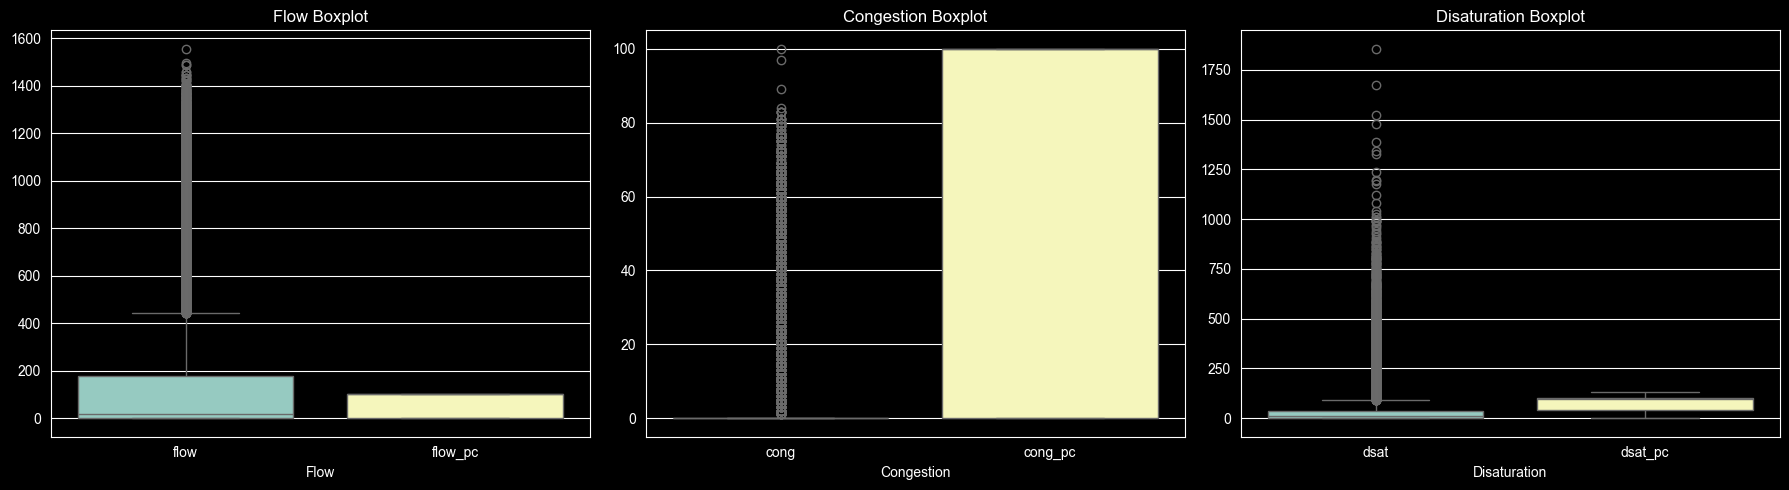

In [46]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data=df_traffic_flow.filter(like='flow'))
plt.title('Flow Boxplot')
plt.xlabel('Flow')

plt.subplot(1, 3, 2)
sns.boxplot(data=df_traffic_flow.filter(like='cong'))
plt.title('Congestion Boxplot')
plt.xlabel('Congestion')

plt.subplot(1, 3, 3)
sns.boxplot(data=df_traffic_flow.filter(like='dsat'))
plt.title('Disaturation Boxplot')
plt.xlabel('Disaturation')

plt.tight_layout()
plt.show()

In [47]:
print(f"Unique Sites: {df_traffic_flow['site_id'].nunique()}")
print(f"Count per site: \n {df_traffic_flow['site_id'].value_counts()}")


Unique Sites: 61
Count per site: 
 site_id
N01111D    17373
N01111C    17373
N01111R    17373
N01111M    17373
N01111N    17373
           ...  
N03111B    17372
N03111J    17372
N03111M    16136
N02131L    15270
N03121D     9554
Name: count, Length: 61, dtype: int64


Print visualisations of the distribution of the variables:

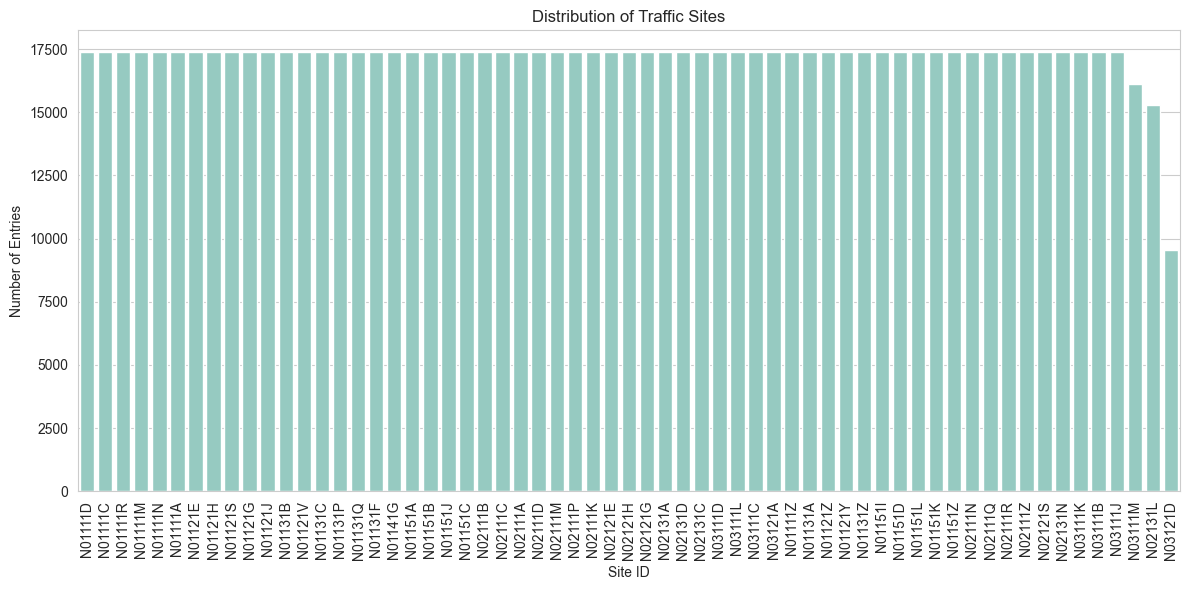

In [48]:
# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a bar plot for the 'site_id' column
plt.figure(figsize=(12, 6))
sns.countplot(data=df_traffic_flow, x='site_id', order=df_traffic_flow['site_id'].value_counts().index)
plt.title('Distribution of Traffic Sites')
plt.xlabel('Site ID')
plt.ylabel('Number of Entries')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


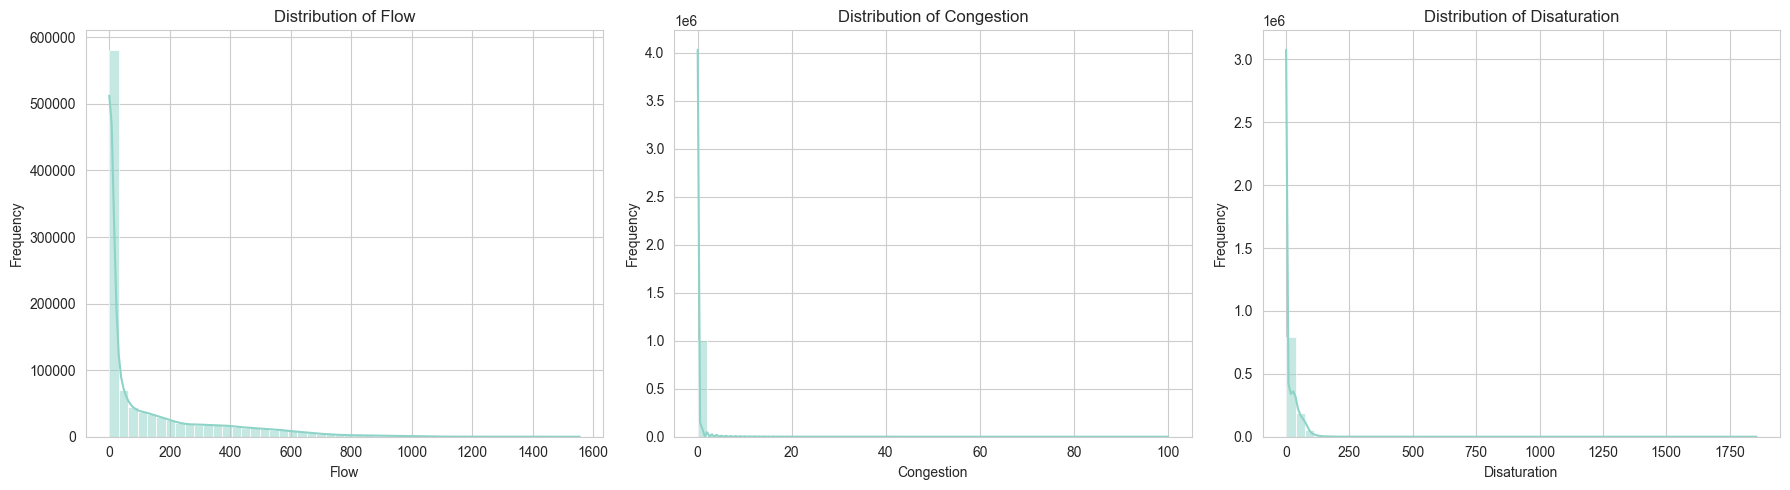

In [49]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(df_traffic_flow['flow'], bins=50, kde=True)
plt.title('Distribution of Flow')
plt.xlabel('Flow')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
sns.histplot(df_traffic_flow['cong'], bins=50, kde=True)
plt.title('Distribution of Congestion')
plt.xlabel('Congestion')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
sns.histplot(df_traffic_flow['dsat'], bins=50, kde=True)
plt.title('Distribution of Disaturation')
plt.xlabel('Disaturation')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Classification:
Build a classification model to predict traffic congestion (cong) based on the provided traffic flow data.

Use the prediction categories 1 (free flow) to 5 (severe congestion) and use the quantils per site as classifier.

Split the data into training, testing and validation sets (60-20-20), train the regression model (multi layer perceptron), and evaluate its performance by calculating and visualizing the confusion matrix, precision, recall, and plotting the ROC curve with a legend. Finally, provide a summary of the model's performance.

# Step 1: Preprocessing & Label Creation

Create the target 'cong_class'

| Class | Meaning            |
|-------|--------------------|
| 0     | No congestion (0%) |
| 1     | Low congestion     |
| 2     | Moderate           |
| 3     | High               |
| 4     | Severe             |

**cong:**
Congestion is directly measured from the detector. If the detector is placed beyond the normal end of queue in the street it is rarely covered by stationary traffic, except of course when congestion occurs. If any detector shows standing traffic for the whole of an interval this is recorded. The number of intervals of congestion in any cycle is also recorded.

*The percentage congestion is calculated from:*
'# of congested intervals x 4 x 100 cycle time in seconds.
This percentage of congestion is available to view and more importantly for the optimisers to take into account.

In [50]:
df_traffic_flow.groupby('site_id')['cong'].head()


0          0
1          0
2          0
3          0
4          0
          ..
1000016    0
1000031    0
1000035    0
1000037    0
1000051    0
Name: cong, Length: 305, dtype: Int64

In [51]:
def classify_congestion(group):
    group = group.copy()

    # Initialize result with default class (0 = no congestion)
    result = pd.Series(0, index=group.index, dtype=int)

    # Select non-zero values
    non_zero_idx = group[group > 0].index
    non_zero = group.loc[non_zero_idx]

    # If not enough variation, assign class 1 (low congestion)
    if len(non_zero) < 5 or non_zero.nunique() < 2:
        result.loc[non_zero_idx] = 1
        return result

    # Apply qcut safely
    try:
        quantiles = pd.qcut(
            non_zero,
            4,
            labels=False,
            duplicates='drop'
        ) + 1  # classes 1–4

        # Assign using aligned indices
        result.loc[quantiles.index] = quantiles.astype(int)

    except ValueError:
        # fallback if qcut still fails
        result.loc[non_zero_idx] = 1

    return result

In [ ]:
#def classify_congestion(group):
#    # Separate zero congestion (very common)
#    zero_mask = group == 0
#
#    # For non-zero values, use percentiles
#    non_zero = group[~zero_mask]
#
#    if len(non_zero) < 5:
#        # fallback if too little data
#        return pd.Series([1]*len(group), index=group.index)
#
#    quantiles = pd.qcut(non_zero, 4, labels=False, duplicates='drop') + 2
#    # +2 because class 1 is reserved for zero
#
#    result = pd.Series(index=group.index, dtype=int)
#
#    # Assign classes
#    result[zero_mask] = 1              # no congestion
#    result[~zero_mask] = quantiles    # 2–5
#
#    return result

In [52]:
df_traffic_flow['target'] = (
    df_traffic_flow
    .groupby('site_id')['cong']
    .transform(classify_congestion)
)


In [53]:
class_counts = df_traffic_flow['target'].value_counts().sort_index()
class_percent = df_traffic_flow['target'].value_counts(normalize=True).sort_index() * 100

print("Counts:\n", class_counts)
print("\nPercent:\n", class_percent)

Counts:
 target
0    984133
1     31895
2     11675
3     12263
4      8609
Name: count, dtype: int64

Percent:
 target
0    93.854326
1     3.041747
2     1.113416
3     1.169492
4     0.821019
Name: proportion, dtype: float64


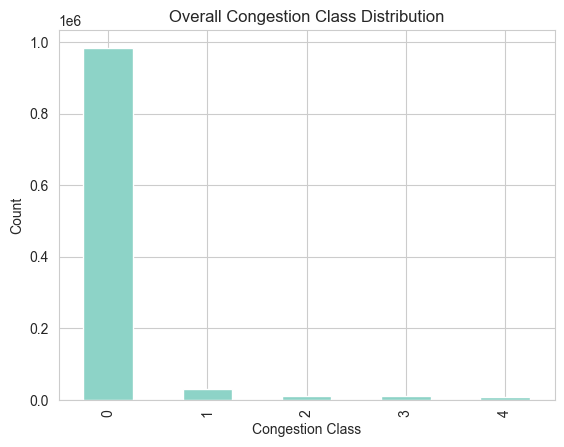

In [54]:
class_counts.plot(kind='bar')
plt.title("Overall Congestion Class Distribution")
plt.xlabel("Congestion Class")
plt.ylabel("Count")
plt.show()

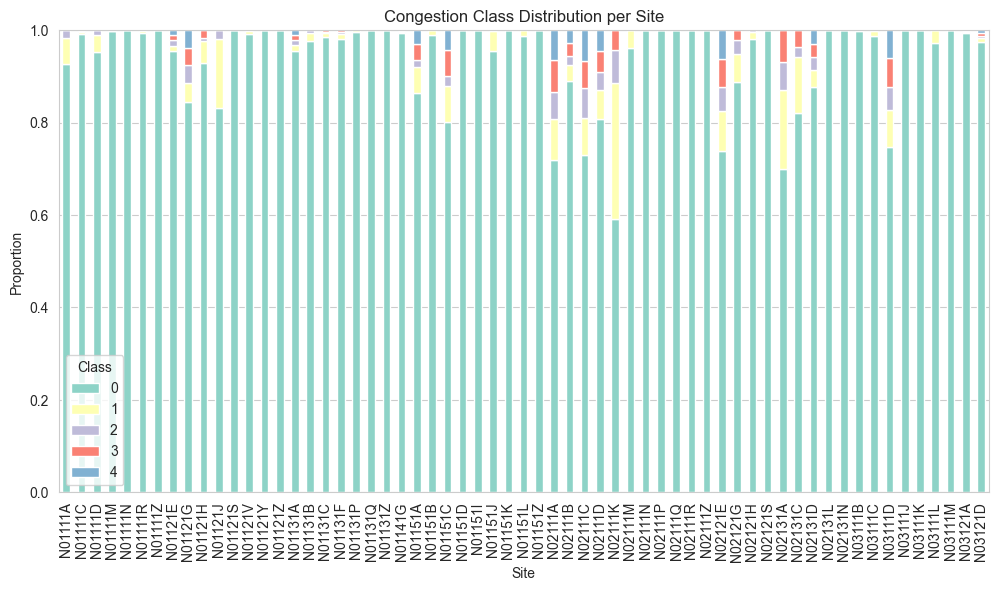

In [55]:
site_class_dist = (
    df_traffic_flow
    .groupby('site_id')['target']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)

site_class_dist.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6)
)

plt.title("Congestion Class Distribution per Site")
plt.xlabel("Site")
plt.ylabel("Proportion")
plt.legend(title="Class")
plt.show()


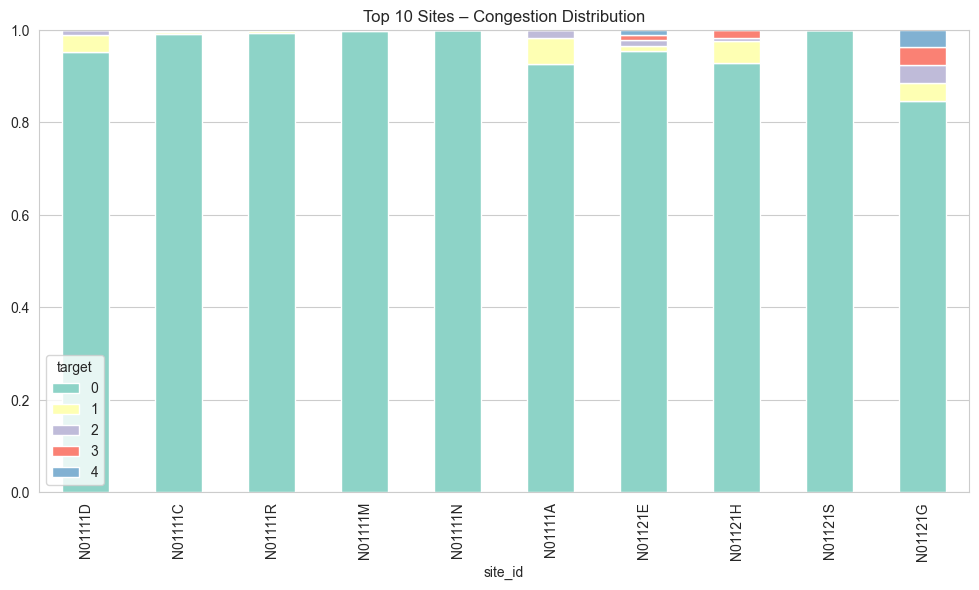

In [56]:
top_sites = df_traffic_flow['site_id'].value_counts().head(10).index

subset = site_class_dist.loc[top_sites]

subset.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6)
)

plt.title("Top 10 Sites – Congestion Distribution")
plt.show()


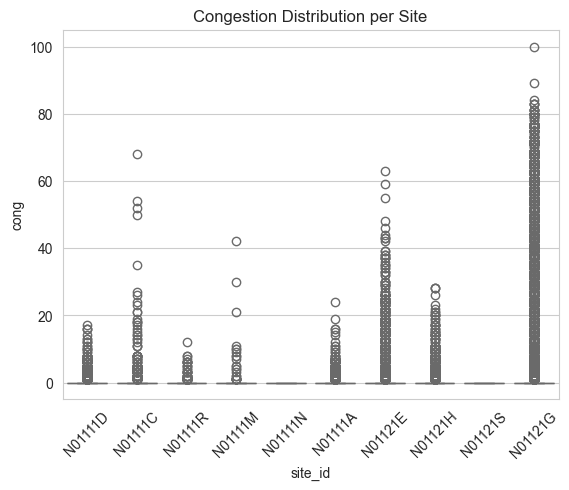

In [57]:
top_sites = df_traffic_flow['site_id'].value_counts().head(10).index

sns.boxplot(
    data=df_traffic_flow[df_traffic_flow['site_id'].isin(top_sites)],
    x='site_id',
    y='cong'
)

plt.xticks(rotation=45)
plt.title("Congestion Distribution per Site")
plt.show()


In [58]:
df_traffic_flow['target'].value_counts(normalize=True)

target
0    0.938543
1    0.030417
3    0.011695
2    0.011134
4    0.008210
Name: proportion, dtype: float64

In [59]:
print(f"max value over all: {df_traffic_flow['cong'].max()}")
print(f"min value over all: {df_traffic_flow['cong'].min()}")
print(f"distribution in 5 bins: \n {df_traffic_flow['cong'].value_counts(bins=5)}")

max value over all: 100
min value over all: 0
distribution in 5 bins: 
 (-0.101, 20.0]    1042431
(20.0, 40.0]         4596
(40.0, 60.0]         1296
(60.0, 80.0]          238
(80.0, 100.0]          14
Name: count, dtype: int64


## 2. Feature Selection & Encoding

We'll use flow, dsat, and 'day_of_week' (encoded) as features.
We ignore Objectid, date, and times for this baseline.


In [62]:
# 1. Convert start_time to fractional hour (e.g., 14:30 -> 14.5)
df_traffic_flow['hour'] = pd.to_datetime(df_traffic_flow['start_time'], format='%H:%M').dt.hour
df_traffic_flow['minute'] = pd.to_datetime(df_traffic_flow['start_time'], format='%H:%M').dt.minute
df_traffic_flow['time_float'] = df_traffic_flow['hour'] + df_traffic_flow['minute'] / 60

In [63]:
# 2. Cyclical Encoding for Time (Essential for MLPs)
# This teaches the model that 00:00 follows 23:45
df_traffic_flow['sin_time'] = np.sin(2 * np.pi * df_traffic_flow['time_float'] / 24)
df_traffic_flow['cos_time'] = np.cos(2 * np.pi * df_traffic_flow['time_float'] / 24)

In [64]:
# 3. Map Days to Numbers
day_map = {'MO':0, 'TU':1, 'WE':2, 'TH':3, 'FR':4, 'SA':5, 'SU':6}
df_traffic_flow['day_num'] = df_traffic_flow['day_of_week'].map(day_map)


In [65]:
# FIX: Fill NaNs (rows that couldn't be binned) with 0 (Class 1)
df_traffic_flow['target'] = df_traffic_flow['target'].fillna(0).astype(int)

# Select Features: Flow and Dsat are the primary indicators
features = ['flow', 'flow_pc', 'dsat', 'dsat_pc', 'sin_time', 'cos_time', 'day_num']
X = df_traffic_flow[features].values
y = df_traffic_flow['target'].values

# Double check features for NaNs as well
X = df_traffic_flow[features].fillna(0).values
y = df_traffic_flow['target'].values

In [66]:
# Convert to Series and get percentages
distribution = pd.Series(y).value_counts(normalize=True).sort_index() * 100

print("Congestion Class Distribution (%):")
print(distribution)

df_traffic_flow['target'].value_counts(normalize=True)

Congestion Class Distribution (%):
0    93.854326
1     3.041747
2     1.113416
3     1.169492
4     0.821019
Name: proportion, dtype: float64


target
0    0.938543
1    0.030417
3    0.011695
2    0.011134
4    0.008210
Name: proportion, dtype: float64

## Split Data (60-20-20)

In [67]:
# clean first
# 1. Check for and drop any rows with NaN in features or target
original_count = len(df_traffic_flow)
df_traffic_flow = df_traffic_flow.dropna(subset=features + ['target'])

# 2. Check for Infinite values (rare, but happens with flow/dsat pc)
df_traffic_flow = df_traffic_flow.replace([np.inf, -np.inf], np.nan).dropna(subset=features)

print(f"Dropped {original_count - len(df_traffic_flow)} rows containing NaN or Inf.")

# Now proceed to X, y assignment and scaling
X = df_traffic_flow[features].values.astype('float32') # Force float32 for GPU
y = df_traffic_flow['target'].values.astype('int32')

Dropped 0 rows containing NaN or Inf.


In [68]:
val_proportion = cfg['data_split']['validation']
test_proportion = cfg['data_split']['test']
val_test = val_proportion + test_proportion

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=val_proportion+test_proportion, random_state=cfg['project']['random_seed'])
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=val_proportion/val_test, random_state=cfg['project']['random_seed'])

In [69]:
# Convert to Series and get percentages
print(y_train.size)
distribution = pd.Series(y_train).value_counts(normalize=True).sort_index() * 100

print("Congestion Class Distribution (%):")
print(distribution)

# Convert to Series and get percentages
print(y_test.size)
distribution = pd.Series(y_test).value_counts(normalize=True).sort_index() * 100

print("Congestion Class Distribution (%):")
print(distribution)

# Convert to Series and get percentages
print(y_val.size)
distribution = pd.Series(y_val).value_counts(normalize=True).sort_index() * 100

print("Congestion Class Distribution (%):")
print(distribution)

629145
Congestion Class Distribution (%):
0    93.832741
1     3.050966
2     1.121204
3     1.166663
4     0.828426
Name: proportion, dtype: float64
209715
Congestion Class Distribution (%):
0    93.912691
1     2.999785
2     1.085759
3     1.168252
4     0.833512
Name: proportion, dtype: float64
209715
Congestion Class Distribution (%):
0    93.860716
1     3.056052
2     1.117707
3     1.179219
4     0.786305
Name: proportion, dtype: float64


## 4. Scaling (Essential for MLP)

In [70]:
# Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [71]:
print(f"count NAN values in flow: {df_traffic_flow['flow'].isna().sum()}")
print(f"count NAN values in flow_pc: {df_traffic_flow['flow_pc'].isna().sum()}")
print(f"count NAN values in dsat: {df_traffic_flow['dsat'].isna().sum()}")
print(f"count NAN values in day_num: {df_traffic_flow['day_num'].isna().sum()}")
print(f"count NAN values in cong: {df_traffic_flow['cong'].isna().sum()}")
print(f"count NAN values in target: {df_traffic_flow['target'].isna().sum()}")

count NAN values in flow: 0
count NAN values in flow_pc: 0
count NAN values in dsat: 0
count NAN values in day_num: 0
count NAN values in cong: 0
count NAN values in target: 0


# Step 2: Training the MLP Classifier
We will use a hidden layer architecture (e.g., 64x32) which is a good starting point for this data size.

In [72]:
print(np.isnan(y_train).sum())

0


In [73]:
from sklearn.utils import class_weight
import numpy as np

# Calculate weights: Higher weight for smaller classes
weights = class_weight.compute_class_weight(
    class_weight=cfg['training']['class_weights'],
    classes=np.unique(y_train),
    y=y_train
)

# Convert to a dictionary format for Keras
class_weight_dict = dict(enumerate(weights))

print("Calculated Weights:", class_weight_dict)
# You will likely see Class 1 weight ≈ 0.2 and Class 5 weight ≈ 20.0

Calculated Weights: {0: np.float64(0.21314521702600517), 1: np.float64(6.555300859598854), 2: np.float64(17.83796427558832), 3: np.float64(17.14291553133515), 4: np.float64(24.142171910974675)}


In [74]:
# 1. Stop when validation loss hasn't improved for 5 epochs
early_stop = EarlyStopping(
    monitor=cfg['callbacks']['early_stopping']['monitor'],
    patience=cfg['callbacks']['early_stopping']['patience'], # How many epochs to wait before stopping
    restore_best_weights=cfg['callbacks']['early_stopping']['restore_best_weights'],
    verbose=1
)

# 2. Lower the learning rate if the model gets stuck
reduce_lr = ReduceLROnPlateau(
    monitor=cfg['callbacks']['reduce_lr_on_plateau']['monitor'],
    factor=cfg['callbacks']['reduce_lr_on_plateau']['factor'],               # Multiply learning rate by 0.2
    patience=cfg['callbacks']['reduce_lr_on_plateau']['patience'],               # Wait 3 epochs before reducing
    min_lr=cfg['callbacks']['reduce_lr_on_plateau']['min_lr'],
    verbose=1
)

model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)), # New way to define input
    layers.BatchNormalization(),             # Stabilizes the inputs
    layers.Dense(cfg["model"]["hidden_layers"][0]["units"], activation=cfg["model"]["hidden_layers"][0]["activation"]),
    layers.Dropout(cfg["model"]["hidden_layers"][0]["dropout"]),
    layers.Dense(cfg["model"]["hidden_layers"][1]["units"], activation=cfg["model"]["hidden_layers"][0]["activation"]),
    layers.Dense(5, activation=cfg["model"]["output_layer"]["activation"])
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=cfg["training"]["optimizer"]["learning_rate"]), # Explicit learning rate
    loss=cfg["training"]["loss_function"],
    metrics=[cfg["training"]["metrics"]]
)

# Training with the T4 GPU
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=cfg["training"]["epochs"],
    batch_size=cfg["training"]["batch_size"],
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/50


2026-05-28 23:50:47.021029: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


615/615 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7225 - loss: 1.2270 - val_accuracy: 0.7250 - val_loss: 0.6566 - learning_rate: 0.0010
Epoch 2/50
615/615 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7405 - loss: 1.1568 - val_accuracy: 0.7441 - val_loss: 0.6319 - learning_rate: 0.0010
Epoch 3/50
615/615 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7533 - loss: 1.1393 - val_accuracy: 0.7546 - val_loss: 0.6104 - learning_rate: 0.0010
Epoch 4/50
615/615 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7616 - loss: 1.1298 - val_accuracy: 0.7585 - val_loss: 0.5952 - learning_rate: 0.0010
Epoch 5/50
615/615 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7660 - loss: 1.1228 - val_accuracy: 0.7675 - val_loss: 0.5784 - learning_rate: 0.0010
Epoch 6/50
615/615 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7708 - loss: 1.1151 - val_accuracy: 0.7677 - val_loss: 0.5783 - learning_rate: 0.0010
Epoch 7/50
615/615 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7724 - loss: 1.1128 - val_accurac

## Step 3: Evaluation & Visualization
# Confusion Matrix & Metrics

 438/6554 ━━━━━━━━━━━━━━━━━━━━ 2s 344us/step

2026-05-28 23:51:53.350545: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


6554/6554 ━━━━━━━━━━━━━━━━━━━━ 2s 360us/step


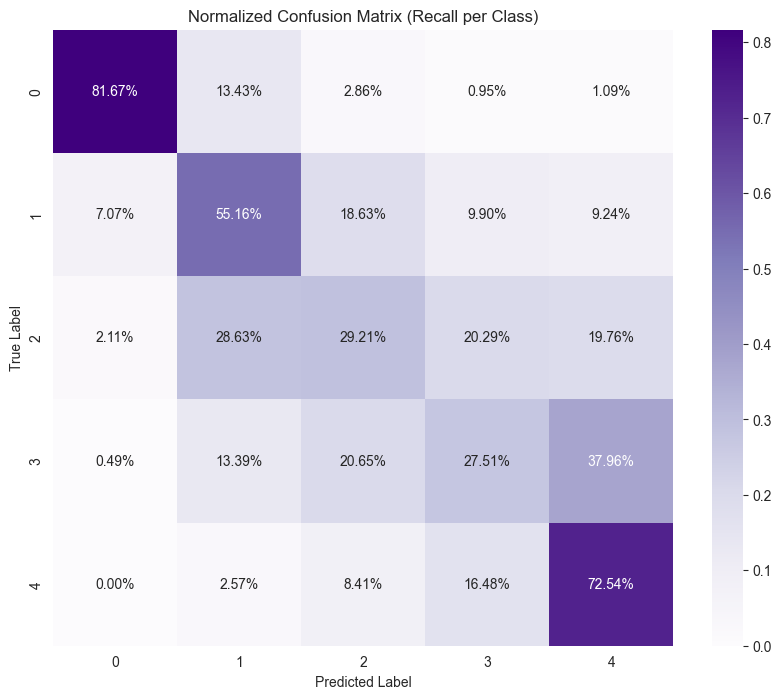

In [75]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Predictions
y_probs = model.predict(X_test)
y_pred = np.argmax(y_probs, axis=1)

# Binarize labels for multi-class evaluation
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])

# Calculate the normalized matrix
# 'true' normalizes over the rows (actual labels)
cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Purples')

plt.title("Normalized Confusion Matrix (Recall per Class)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


## Precision-Recall Curve

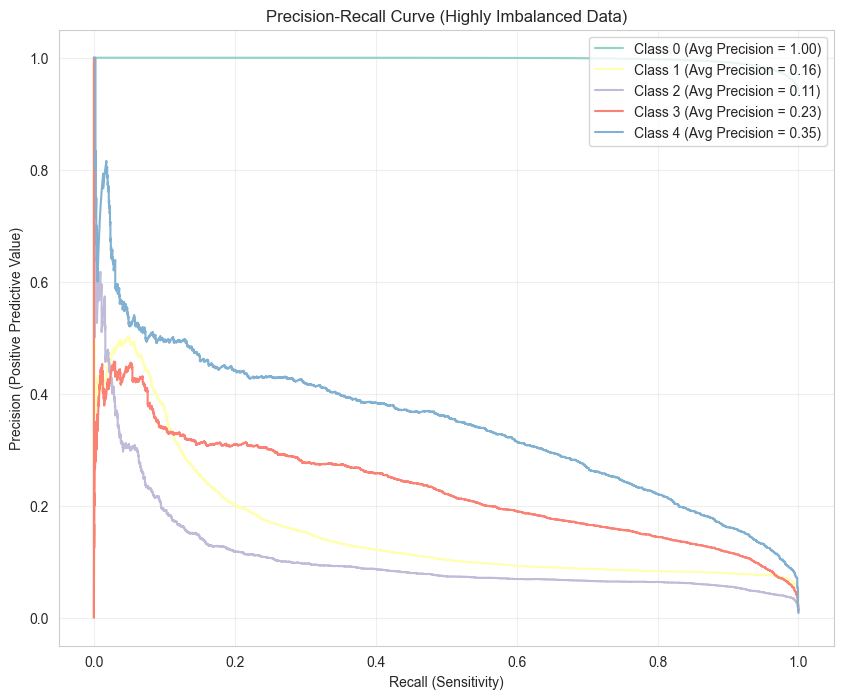

In [76]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 8))

for i in range(5):
    # Calculate precision and recall for each class
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_probs[:, i])
    avg_precision = average_precision_score(y_test_bin[:, i], y_probs[:, i])

    plt.plot(recall, precision, label=f'Class {i} (Avg Precision = {avg_precision:0.2f})')

plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (Positive Predictive Value)')
plt.title('Precision-Recall Curve (Highly Imbalanced Data)')
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.show()

## Multi-class ROC Curve
Since we have 5 classes, we plot a curve for each class using the "One-vs-Rest" approach.

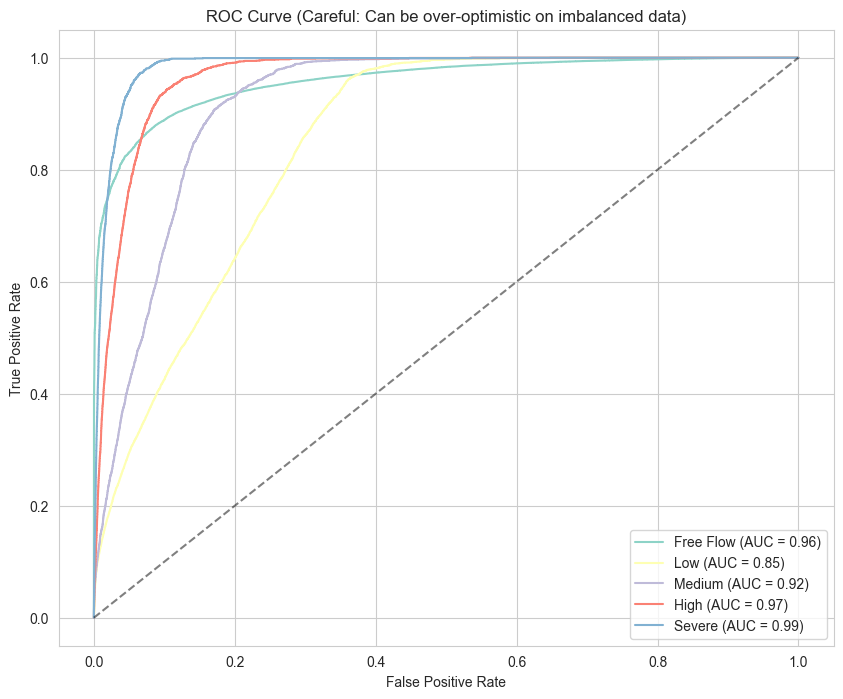

In [77]:
# ROC Curve
class_names = ['Free Flow', 'Low', 'Medium', 'High', 'Severe']
plt.figure(figsize=(10, 8))
for i in range(5):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("ROC Curve (Careful: Can be over-optimistic on imbalanced data)")
plt.legend()
plt.show()

## 4. Saving Model Artifacts
To ensure reproducibility and deployment readiness, we save the trained model, the preprocessing scaler, and a copy of the configuration.

In [79]:
import pickle
import shutil
from pathlib import Path

# Define output directory
output_dir = Path('../outputs/model_artefacts')
output_dir.mkdir(parents=True, exist_ok=True)

# 1. Save the Keras Model
model_path = output_dir / 'mlp_model.keras'
model.save(model_path)
print(f"Model saved to: {model_path}")

# 2. Save the StandardScaler using pickle
scaler_path = output_dir / 'scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"Scaler saved to: {scaler_path}")

# 3. Save a copy of the configuration for reproducibility
config_save_path = output_dir / 'config_mlp_v1.yaml'
shutil.copy('../config_mlp_v1.yaml', config_save_path)
print(f"Config copy saved to: {config_save_path}")

# 4. Reference existing metadata
print(f"Fair4ML metadata is available at: ../outputs/mlp_classifier_v1.json")

Model saved to: ../outputs/model_artefacts/mlp_model.keras
Scaler saved to: ../outputs/model_artefacts/scaler.pkl
Config copy saved to: ../outputs/model_artefacts/config_mlp_v1.yaml
Fair4ML metadata is available at: ../outputs/mlp_classifier_v1.json
